In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
df = pd.read_csv('zomato_data.csv')
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [5]:
def handleRate(value):
    value = str(value).split('/')
    value = value[0]
    return float(value)
df['rate']=df['rate'].apply(handleRate)
print(df.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


Text(0.5, 0, 'type of restaurant')

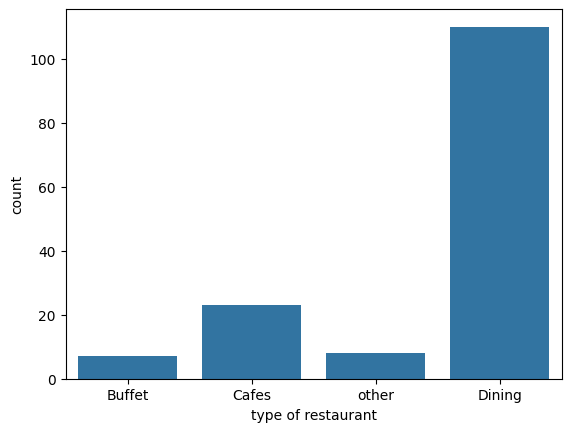

In [ ]:
# RESTAURANTS CUSTOMERS MAINLY ORDER FROM
sns.countplot(x=df['listed_in(type)'])
plt.xlabel('type of restaurant')

Text(0, 0.5, 'votes')

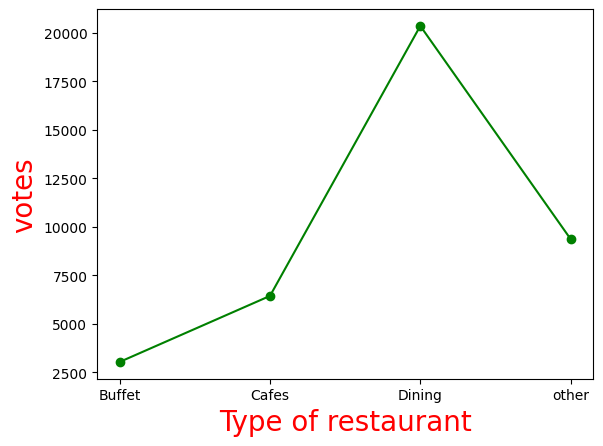

In [ ]:
# HOW MANY VOTES RESTAURANTS GOT
grouped_data = df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes':grouped_data})
plt.plot(result, c="green", marker="o")
plt.xlabel("Type of restaurant", c="red", size=20)
plt.ylabel("votes",c= "red", size=20)

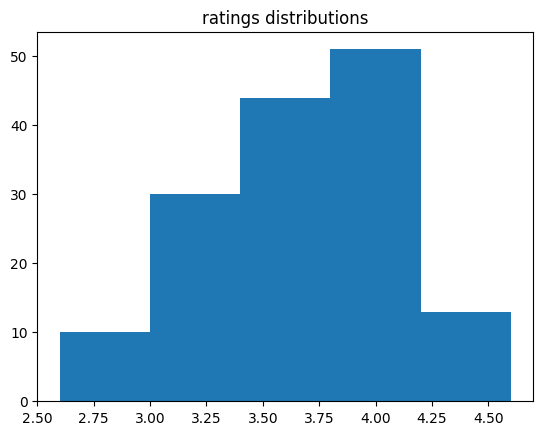

In [ ]:
# RATINGS OF MAJORITY RESTAURANTS
plt.hist(df['rate'], bins=5)
plt.title("ratings distributions")
plt.show()

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

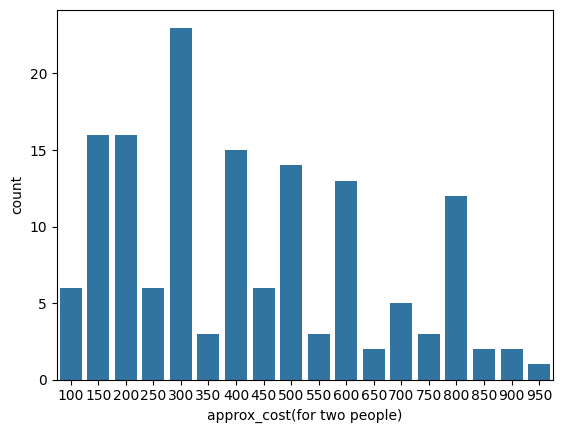

In [ ]:
# AVERAGE COUPLE SPENDINGS
couple_spend = df['approx_cost(for two people)']
sns.countplot(x=couple_spend)

<Axes: xlabel='online_order', ylabel='rate'>

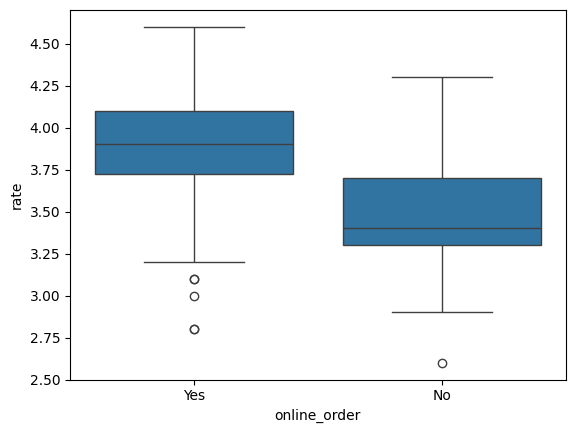

In [13]:
# WHICH MODE RECEIVE MAXIMUM RATING
plt.Figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = df)

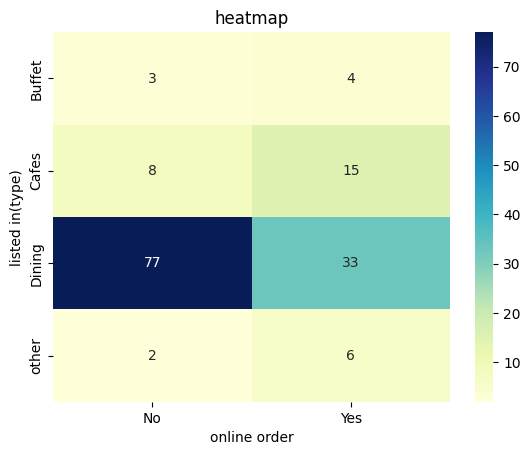

In [ ]:
# RESTAURANTS WITH MORE OFFLINE ORDERS 
pivot_table = df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value = 0)
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt='d')
plt.title("heatmap")
plt.xlabel("online order")
plt.ylabel("listed in(type)")
plt.show()